In [2]:
import numpy as np 
import pylab as plt 
import networkx as nx 
from projector import MDSTorusProjector

In [3]:
def torus_delta(p, q):
    """Shortest displacement from p to q on unit square torus (per-coordinate in [-0.5, 0.5))."""
    return ((q - p + 0.5) % 1.0) - 0.5

def torus_edge_segments(p, q, eps=1e-12):
    """
    Return list of (a_plot, b_plot) segments to draw the shortest torus geodesic between p and q,
    plotted in the fundamental domain [0,1]x[0,1], split at boundary crossings.

    p, q are assumed to be in [0,1)^2.
    """
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    d = torus_delta(p, q)
    r = p + d  # endpoint in covering space (may lie outside [0,1) )

    ts = [0.0, 1.0]

    # boundary crossings for each coordinate
    for k in (0, 1):
        dk = d[k]
        if abs(dk) < eps:
            continue

        # Determine which boundary is crossed (if any) based on direction and endpoint r
        if dk > 0 and r[k] > 1.0 + eps:
            b = 1.0
        elif dk < 0 and r[k] < 0.0 - eps:
            b = 0.0
        else:
            continue

        t = (b - p[k]) / dk
        if eps < t < 1.0 - eps:
            ts.append(float(t))

    ts = sorted(set(ts))

    segs = []
    for t0, t1 in zip(ts[:-1], ts[1:]):
        a = p + t0 * d
        b = p + t1 * d

        # Choose a single tile shift so BOTH endpoints land in the same plotted tile.
        mid = 0.5 * (a + b)
        tile = np.floor(mid)  # integer vector, typically in {-1,0,1}^2 here

        a_plot = a - tile
        b_plot = b - tile

        # Numerical guard: keep within [0,1] for plotting
        a_plot = np.clip(a_plot, 0.0, 1.0)
        b_plot = np.clip(b_plot, 0.0, 1.0)

        segs.append((a_plot, b_plot))

    return segs

def plot_embedding_with_torus_edges(X, G, outpath="output.png",
                                   s=10, node_alpha=0.9,
                                   edge_alpha=0.10, edge_lw=0.4, 
                                   colors=None,
                                   ax=None):
    """
    Scatter + edges drawn along shortest torus paths in [0,1)^2.

    X: (N,2) embedding (can be unwrapped; we'll wrap for plotting)
    nodes: list of nodes matching row order of X
    G: networkx graph
    """
    X = np.asarray(X, dtype=np.float64) % 1.0
    idx = {n: i for i, n in enumerate(G.nodes())}

    if ax == None: 
        fig, ax = plt.subplots()
    

    # edges
    for u, v in G.edges():
        i, j = idx[u], idx[v]
        p, q = X[i], X[j]
        for a, b in torus_edge_segments(p, q):
            ax.plot([a[0], b[0]], [a[1], b[1]],
                     color="k", alpha=edge_alpha, lw=edge_lw, zorder=1)

    # points
    ax.scatter(X[:, 0], X[:, 1], s=s, alpha=node_alpha, zorder=2,c=colors if colors else "blue")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    # plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    # plt.savefig(outpath, dpi=200)
    # plt.close()
    return ax

def plot_embedding(X, G, outpath="output.png",
                                   s=10, node_alpha=0.9,
                                   edge_alpha=0.10, edge_lw=0.4, 
                                   colors=None,
                                   ax=None):
    """
    Scatter + edges drawn along shortest torus paths in [0,1)^2.

    X: (N,2) embedding (can be unwrapped; we'll wrap for plotting)
    nodes: list of nodes matching row order of X
    G: networkx graph
    """
    X = np.asarray(X, dtype=np.float64) % 1.0
    idx = {n: i for i, n in enumerate(G.nodes())}

    if ax == None: 
        fig, ax = plt.subplots()
    

    # edges
    for u, v in G.edges():
        i, j = idx[u], idx[v]
        p, q = X[i], X[j]
        ax.plot([p[0], q[0]], [p[1], q[1]],
                    color="k", alpha=edge_alpha, lw=edge_lw, zorder=1)

    # points
    ax.scatter(X[:, 0], X[:, 1], s=s, alpha=node_alpha, zorder=2,c=colors if colors else "blue")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    # plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    # plt.savefig(outpath, dpi=200)
    # plt.close()
    return ax

def periodic_lattice_graph(nx_size: int, ny_size: int, diagonal: bool = False) -> nx.Graph:
    """
    Create a 2D periodic lattice (torus) graph with NetworkX.

    Nodes are (i, j) tuples. Periodic boundaries wrap in both directions.
    If diagonal=True, add 4 diagonal neighbors (8-neighborhood total).
    """
    G = nx.grid_2d_graph(nx_size, ny_size, periodic=True)

    if diagonal:
        # Add diagonal wrap-around edges
        for i in range(nx_size):
            for j in range(ny_size):
                G.add_edge((i, j), ((i + 1) % nx_size, (j + 1) % ny_size))
                G.add_edge((i, j), ((i + 1) % nx_size, (j - 1) % ny_size))

    # Unit weights (optional but explicit)
    nx.set_edge_attributes(G, 1.0, "weight")
    return G

In [4]:
def torus_distance(p,q): 
    return np.linalg.norm(torus_delta(p,q))

def euc_distance(p,q):
    return np.linalg.norm(p-q)

def subsample(max_n, *arrays, seed=42):
    """
    Subsample arrays uniformly at random to at most max_n rows.
    Pass multiple arrays to keep them in sync (e.g. data and labels).
    Returns a single array if one is given, otherwise a tuple.
    """
    n = arrays[0].shape[0]
    if n <= max_n:
        return arrays[0] if len(arrays) == 1 else arrays
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, max_n, replace=False)
    result = tuple(a[idx] for a in arrays)
    return result[0] if len(arrays) == 1 else result

def geodesic_stress(X,d,geod):
    n = X.shape[0]
    num, denom = 0.0, 0.0
    for i in range(n):
        for j in range(i):
            num   += (geod(X[i], X[j]) - d[i,j]) ** 2
            denom += d[i,j] ** 2
    return np.sqrt(num / denom)

def geodesic_matrix(X,geod):
    n = X.shape[0]
    m = np.zeros((n,n))
    for i in range(n): 
        for j in range(i):
            m[i,j] = geod(X[i], X[j])
            m[j,i] = m[i,j]
    return m


def geodesic_distortion(X,d,geod):
    n = X.shape[0]
    num, denom = 0.0, 0.0
    for i in range(n):
        for j in range(i):
            num   += np.abs(geod(X[i], X[j]) - d[i,j])
            denom += d[i,j]
    return num / denom

from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr
def SGS(X,d,geod):
    n = X.shape[0]
    hd = d[np.triu_indices_from(d,k=1)]
    ld = geodesic_matrix(X,geod)
    ld = ld[np.triu_indices_from(d,k=1)]

    return spearmanr(hd,ld).statistic

def geodesic_NP(X,d,geod,rg = 2):
    """
    How well do the local neighborhoods represent the theoretical neighborhoods?
    Closer to 1 is better.
    Measure of percision: ratio of true positives to true positives+false positives
    """
    def get_k_embedded(X,k_t,geod):
        dist_mat = geodesic_matrix(X,geod)
        return [np.argsort(dist_mat[i])[1:len(k_t[i])+1] for i in range(len(dist_mat))]

    k_theory = [np.where((d[i] <= rg) & (d[i] > 0))[0] for i in range(len(d))]

    k_embedded = get_k_embedded(X,k_theory,geod)


    NP = 0
    for i in range(len(X)):
        if len(k_theory[i]) <= 0:
            continue
        intersect = np.intersect1d(k_theory[i],k_embedded[i]).size
        jaccard = intersect / (2*k_theory[i].size - intersect)

        NP += jaccard

    return NP / len(X)

def shepard_diagram(X, d, geod, ax=None, s=1, alpha=0.2, label=None, max_pairs=5000, seed=42):
    """
    Scatter plot of input dissimilarities vs embedding distances.
    Points on the y=x diagonal indicate perfect distance preservation.
    Pairs are subsampled to max_pairs for readability.
    """
    hd = d[np.triu_indices_from(d, k=1)]
    ld = geodesic_matrix(X, geod)
    ld = ld[np.triu_indices_from(d, k=1)]

    hd, ld = subsample(max_pairs, hd, ld, seed=seed)

    if ax is None:
        _, ax = plt.subplots()

    ax.scatter(hd, ld, s=s, alpha=alpha, label=label)

    lim_max = max(hd.max(), ld.max())
    ax.plot([0, lim_max], [0, lim_max], color="k", lw=1, linestyle="--")

    ax.set_xlabel("Input distance")
    ax.set_ylabel("Embedding distance")

    return ax


In [5]:
def apsp_distance_matrix(G: nx.Graph, weight: str = "weight") -> tuple[np.ndarray, list]:
    """
    Compute all-pairs shortest path (APSP) distance matrix using NetworkX.

    Returns:
    D: (N,N) float64 distance matrix
    nodes: list of nodes in the order used for D
    """
    nodes = list(G.nodes())
    idx = {n: k for k, n in enumerate(nodes)}
    n = len(nodes)
    D = np.zeros((n, n), dtype=np.float64)

    # all_pairs_dijkstra_path_length works for unit weights too
    for src, dist_dict in nx.all_pairs_dijkstra_path_length(G, weight=weight):
        i = idx[src]
        for dst, d in dist_dict.items():
            D[i, idx[dst]] = float(d)

    return D, nodes

def get_periodic_lattice(nx_size=20,ny_size=20):

    G = periodic_lattice_graph(nx_size, ny_size, diagonal=False)
    D, nodes = apsp_distance_matrix(G)
    return G,D

## Lattice graph

<Axes: >

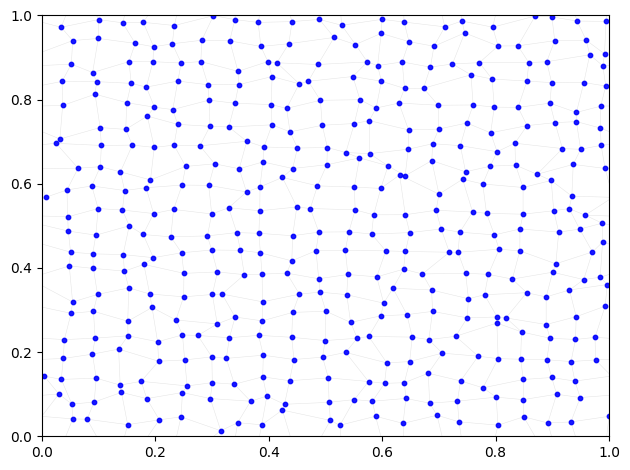

In [19]:
G,D = get_periodic_lattice(20,20)

#Normalize or don't
# D /= np.max(D)

proj_torus = MDSTorusProjector()
X_torus = proj_torus.fit_transform(D)

fig, ax = plt.subplots()

plot_embedding_with_torus_edges(X_torus, G, ax=ax)

In [20]:
import pandas as pd

,name,stress,distortion,goodness,NP
0,torus,0.095341,0.081016,0.96640,0.734264
1,Euclidean,0.318421,0.285588,0.67998,0.200000


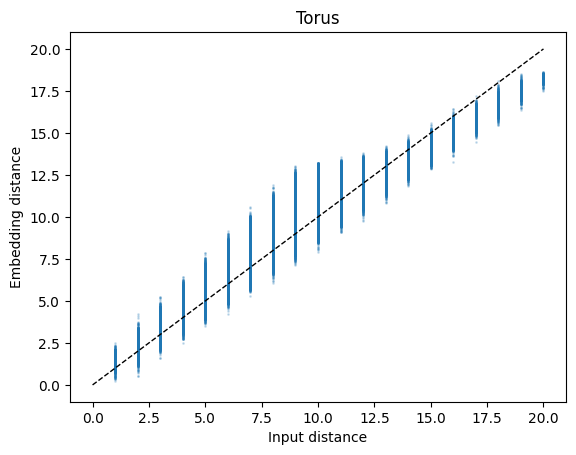

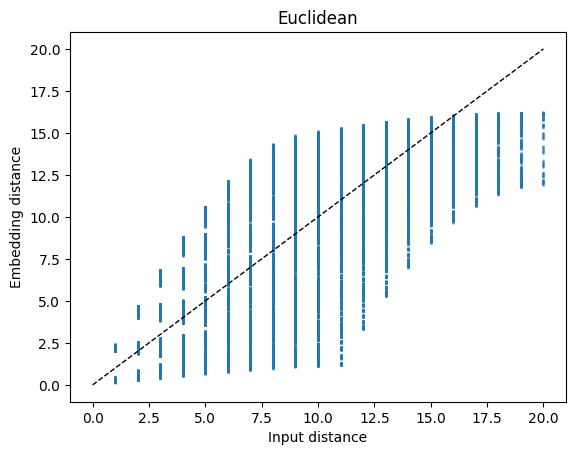

In [21]:
from sklearn.manifold import MDS
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

scaled_torus = lambda p, q: proj_torus.alpha_ * torus_distance(p, q)

stress     = ( geodesic_stress(X_torus,D,scaled_torus),    geodesic_stress(X_euc,D,euc_distance) )
distortion = ( geodesic_distortion(X_torus,D,scaled_torus), geodesic_distortion(X_euc,D,euc_distance) )
goodness   = ( SGS(X_torus,D,scaled_torus),                SGS(X_euc,D,euc_distance) )
NP         = ( geodesic_NP(X_torus,D,scaled_torus),        geodesic_NP(X_euc,D,euc_distance) )

shepard_torus = shepard_diagram(X_torus,D,scaled_torus)
shepard_torus.set_title("Torus")
shepard_euc   = shepard_diagram(X_euc,D,euc_distance)
shepard_euc.set_title("Euclidean")

df = pd.DataFrame({"name": ("torus", "Euclidean"), "stress": stress, "distortion": distortion, "goodness": goodness, "NP": NP})
df

## Grid cells

In [22]:
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

a = np.load("grid_cells_4800.npz")
data, spikes = subsample(2000, a['data'], a['spikes'])

D = pairwise_distances(data)

proj_torus = MDSTorusProjector()
X = proj_torus.fit_transform(D)

Text(0.5, 0.98, 'Firing rates of selected cells by spatial position\n Toroidal embedding')

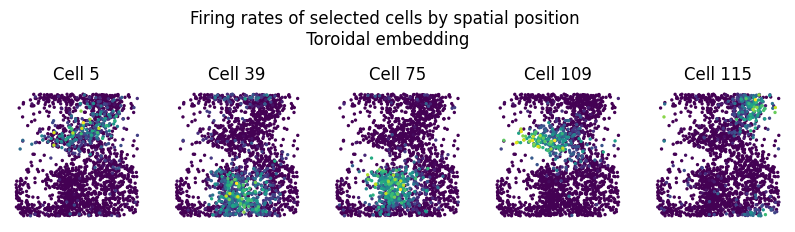

In [23]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

cell_ids = [5, 39, 75, 109, 115] # cells with clearly structured firing pattern

xx = X[:,0]
yy = X[:,1]
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
fig.suptitle("Firing rates of selected cells by spatial position\n Toroidal embedding")

In [24]:
X_torus = X
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

Text(0.5, 0.98, 'Firing rates of selected cells by spatial position\n Euclidean embedding')

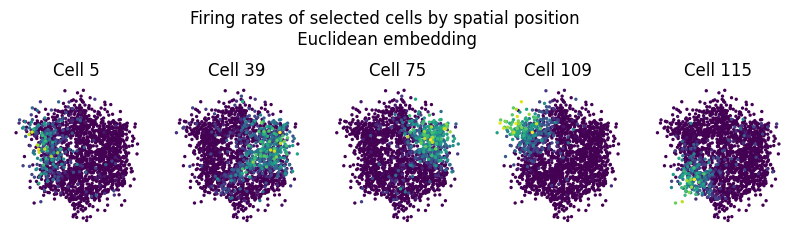

In [25]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

cell_ids = [5, 39, 75, 109, 115] # cells with clearly structured firing pattern

xx = X_euc[:,0]
yy = X_euc[:,1]
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
fig.suptitle("Firing rates of selected cells by spatial position\n Euclidean embedding")

In [ ]:
from sklearn.manifold import MDS
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

scaled_torus = lambda p, q: proj_torus.alpha_ * torus_distance(p, q)

stress     = ( geodesic_stress(X_torus,D,scaled_torus),    geodesic_stress(X_euc,D,euc_distance) )
distortion = ( geodesic_distortion(X_torus,D,scaled_torus), geodesic_distortion(X_euc,D,euc_distance) )
goodness   = ( SGS(X_torus,D,scaled_torus),                SGS(X_euc,D,euc_distance) )
NP         = ( geodesic_NP(X_torus,D,scaled_torus),        geodesic_NP(X_euc,D,euc_distance) )

# shepard_torus = shepard_diagram(X_torus,D,scaled_torus)
# shepard_torus.set_title("Torus")
# shepard_euc   = shepard_diagram(X_euc,D,euc_distance)
# shepard_euc.set_title("Euclidean")

df = pd.DataFrame({"name": ("torus", "Euclidean"), "stress": stress, "distortion": distortion, "goodness": goodness, "NP": NP})
df

## Yoda and Bulldog

In [ ]:
pca = subsample(2000, np.load("yoda_bulldog_pca50.npy"))

D = pairwise_distances(pca[:,:10])
X = MDSTorusProjector().fit_transform(D)

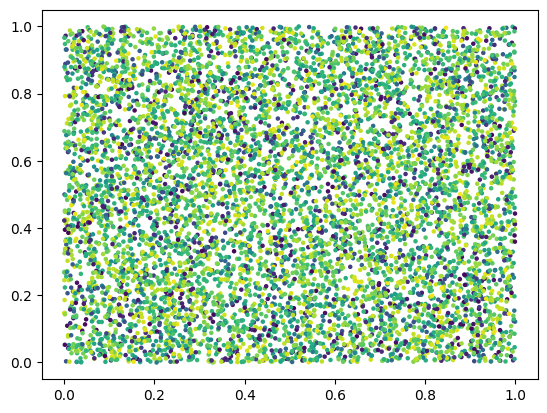

In [ ]:
fig, ax = plt.subplots()
plt.scatter(X[:,0], X[:,1],c=pca[:,3],s=5)

## Block models

In [6]:
G = nx.planted_partition_graph(5, 100, 0.2, 0.01)
# nx.nx_pydot.write_dot(G,"out.gv")
d, nodes = apsp_distance_matrix(G)

proj_torus = MDSTorusProjector()
X_torus = proj_torus.fit_transform(d)

In [7]:
nx.write_adjlist(G,"block.txt")

<Axes: >

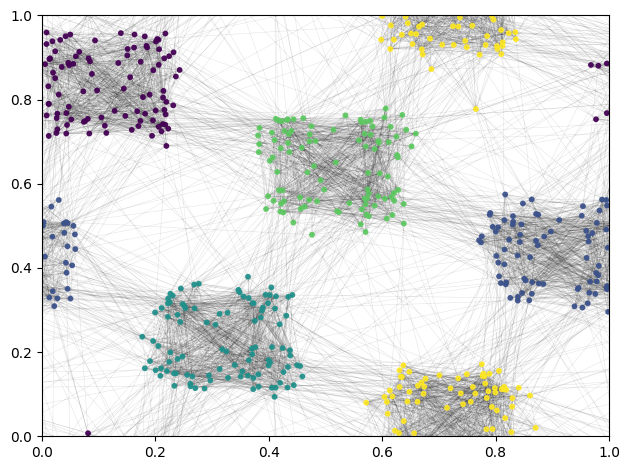

In [8]:
colors = [0] * 100 + [1] * 100 + [2] * 100 + [3] * 100 + [4] * 100
plot_embedding_with_torus_edges(X_torus,G,colors=colors)

In [9]:
D = d
# X_euc = MDS(dissimilarity="precomputed").fit_transform(D)
X = np.load("blcoksgd2.npy")

ValueError: Cannot load file containing pickled data when allow_pickle=False

In [41]:
X_euc /= 2

In [42]:
from sklearn.manifold import MDS
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

scaled_torus = lambda p, q: proj_torus.alpha_ * torus_distance(p, q)

stress     = ( geodesic_stress(X_torus,D,scaled_torus),    geodesic_stress(X_euc,D,euc_distance) )
distortion = ( geodesic_distortion(X_torus,D,scaled_torus), geodesic_distortion(X_euc,D,euc_distance) )
goodness   = ( SGS(X_torus,D,scaled_torus),                SGS(X_euc,D,euc_distance) )
NP         = ( geodesic_NP(X_torus,D,scaled_torus),        geodesic_NP(X_euc,D,euc_distance) )

# shepard_torus = shepard_diagram(X_torus,D,scaled_torus)
# shepard_torus.set_title("Torus")
# shepard_euc   = shepard_diagram(X_euc,D,euc_distance)
# shepard_euc.set_title("Euclidean")

df = pd.DataFrame({"name": ("torus", "Euclidean"), "stress": stress, "distortion": distortion, "goodness": goodness, "NP": NP})
df

,name,stress,distortion,goodness,NP
0,torus,0.293183,0.240881,0.524493,0.543910
1,Euclidean,0.364082,0.310544,0.489229,0.512067


In [36]:
# import s_gd2

# I = [u for u,v in G.edges()]
# J = [v for u,v in G.edges()]

# X = s_gd2.layout_convergent(I,J)

In [ ]:
# colors = [0] * 100 + [1] * 100 + [2] * 100 + [3] * 100 + [4] * 100
# plot_embedding(X,G,colors=colors)

In [43]:
k = 7
partitions = [100] * k

G = nx.planted_partition_graph(k, 100, 0.2, 0.01)
d, nodes = apsp_distance_matrix(G)

proj_torus = MDSTorusProjector()
X_torus = proj_torus.fit_transform(d)

In [44]:
D = d
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

<Axes: >

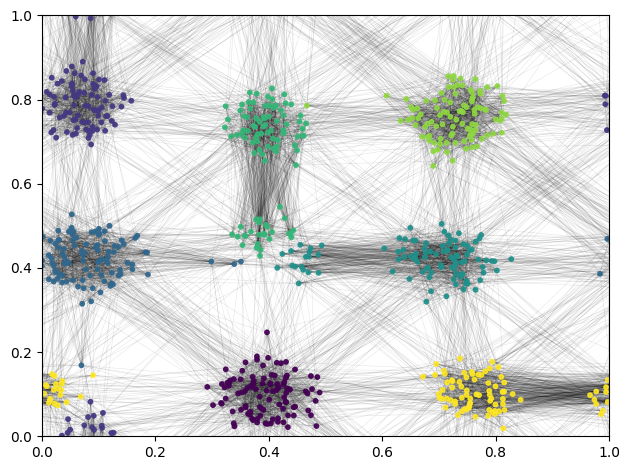

In [45]:
colors = np.array([[i] * 100 for i in range(k)], dtype=int).flatten()
plot_embedding_with_torus_edges(X_torus,G,colors=list(colors))

,name,stress,distortion,goodness,NP
0,torus,0.308817,0.252701,0.403637,0.466541
1,Euclidean,0.386525,0.328445,0.384354,0.436717


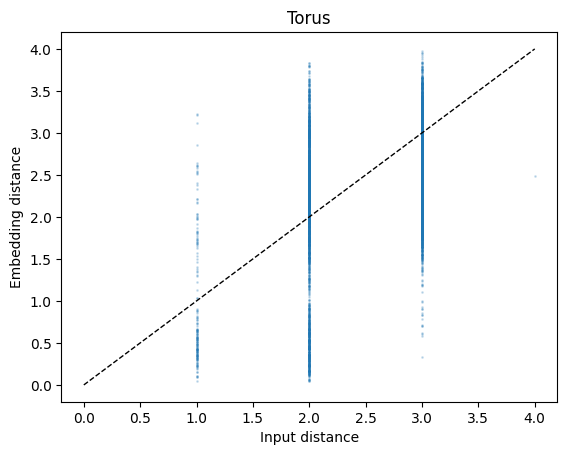

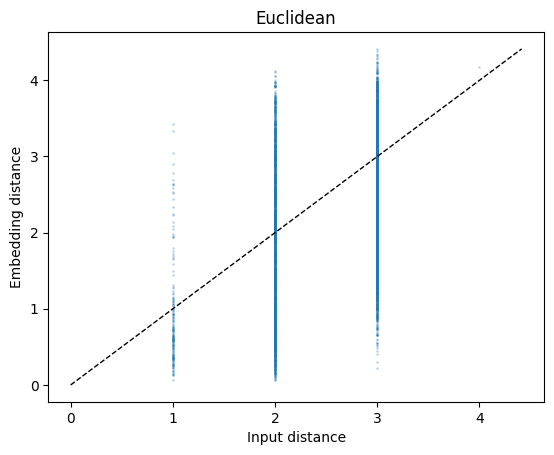

In [ ]:
from sklearn.manifold import MDS
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

scaled_torus = lambda p, q: proj_torus.alpha_ * torus_distance(p, q)

stress     = ( geodesic_stress(X_torus,D,scaled_torus),    geodesic_stress(X_euc,D,euc_distance) )
distortion = ( geodesic_distortion(X_torus,D,scaled_torus), geodesic_distortion(X_euc,D,euc_distance) )
goodness   = ( SGS(X_torus,D,scaled_torus),                SGS(X_euc,D,euc_distance) )
NP         = ( geodesic_NP(X_torus,D,scaled_torus),        geodesic_NP(X_euc,D,euc_distance) )

# shepard_torus = shepard_diagram(X_torus,D,scaled_torus)
# shepard_torus.set_title("Torus")
# shepard_euc   = shepard_diagram(X_euc,D,euc_distance)
# shepard_euc.set_title("Euclidean")

df = pd.DataFrame({"name": ("torus", "Euclidean"), "stress": stress, "distortion": distortion, "goodness": goodness, "NP": NP})
df

## Parser for Chen et al. graphs

In [67]:
import json
import glob

def parse_chen_json(path):
    """
    Parse a Chen et al. toroidal graph layout JSON file.

    Node (x, y) pixel coordinates are normalised to [0, 1] per axis.
    All edges are included — both visible (non-wrapping) and hidden
    (boundary-crossing wrap-around) edges.
    APSP distances are computed from the graph topology.

    Returns
    -------
    G : nx.Graph   nodes indexed by 'index' field
    X : (N, 2)     unit torus coordinates, row order matching G.nodes()
    D : (N, N)     APSP distance matrix
    """
    with open(path) as f:
        data = json.load(f)

    nodes = data['graph']['nodes']
    xs = np.array([n['x'] for n in nodes], dtype=float)
    ys = np.array([n['y'] for n in nodes], dtype=float)
    xs = (xs - xs.min()) / (xs.max() - xs.min())
    ys = (ys - ys.min()) / (ys.max() - ys.min())

    G = nx.Graph()
    for n, x, y in zip(nodes, xs, ys):
        G.add_node(n['index'], x=x, y=y)

    for edge in data['graph']['links']:
        G.add_edge(edge['source']['index'], edge['target']['index'])

    X = np.array([[G.nodes[n]['x'], G.nodes[n]['y']] for n in G.nodes()])
    D, _ = apsp_distance_matrix(G)
    return G, X, D


def estimate_alpha(X, D):
    """
    Estimate the torus scale factor alpha for a fixed layout X given
    target distances D, using the closed-form least-squares solution:

        alpha_hat = sum(d_ij * r_ij) / sum(r_ij^2)

    where r_ij = torus_distance(X[i], X[j]).

    This is the same estimator used inside the SGD, applied retroactively
    to any layout whose unit scale is unknown.
    """
    n = X.shape[0]
    num, denom = 0.0, 0.0
    for i in range(n):
        for j in range(i):
            r = torus_distance(X[i], X[j])
            num   += D[i, j] * r
            denom += r * r
    return num / denom


In [1]:
G, X, D = parse_chen_json("chen_test.json")
plot_embedding_with_torus_edges(X, G,edge_alpha=0.7)


NameError: name 'parse_chen_json' is not defined

## Chen graph comparison: given toroidal layout vs MDS torus

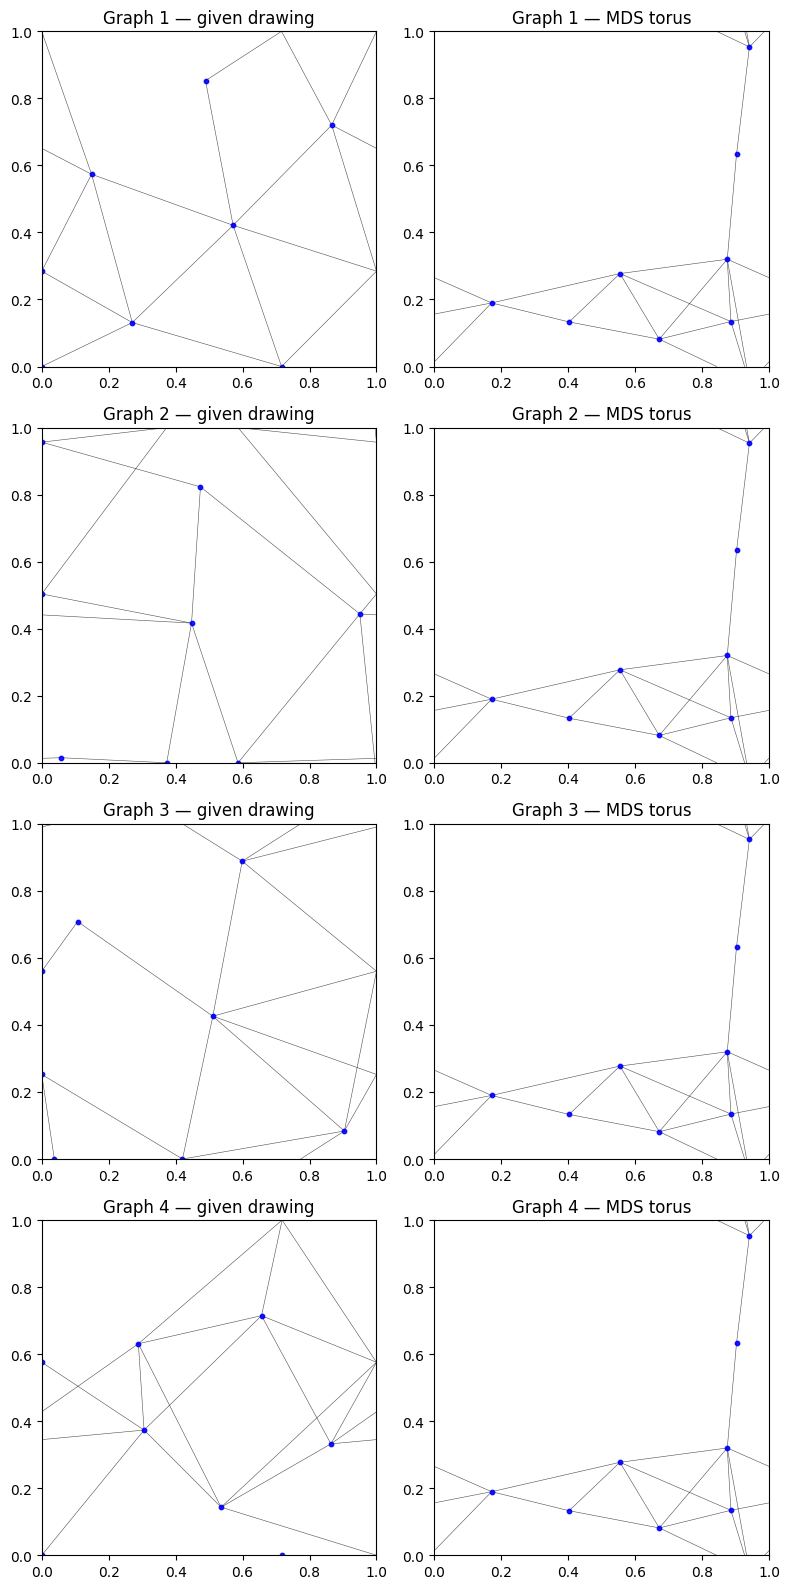

,graph,alpha_given,stress_given,sgs_given,alpha_mds,stress_mds,sgs_mds
0,1,3.258,0.3523,0.2692,3.78,0.1448,0.8378
1,2,2.812,0.4917,0.0369,3.78,0.1448,0.8378
2,3,3.063,0.4367,0.1222,3.78,0.1448,0.8378
3,4,3.079,0.4780,-0.2371,3.78,0.1448,0.8378


In [70]:
paths = sorted(glob.glob("chengraphs/*.json"), key=lambda p: int(p.split("/")[-1].replace(".json", "")))

rows = []
fig, axes = plt.subplots(len(paths), 2, figsize=(8, 4 * len(paths)))

for row_idx, path in enumerate(paths):
    name = path.split("/")[-1].replace(".json", "")
    G, X_given, D = parse_chen_json(path)

    # Scale-normalise the given drawing
    alpha_given = estimate_alpha(X_given, D)
    scaled_given = lambda p, q, a=alpha_given: a * torus_distance(p, q)

    # MDS torus
    proj = MDSTorusProjector()
    X_mds = proj.fit_transform(D)
    alpha_mds = proj.alpha_
    scaled_mds = lambda p, q, a=alpha_mds: a * torus_distance(p, q)

    stress_given = geodesic_stress(X_given, D, scaled_given)
    stress_mds   = geodesic_stress(X_mds,   D, scaled_mds)
    sgs_given    = SGS(X_given, D, scaled_given)
    sgs_mds      = SGS(X_mds,   D, scaled_mds)

    rows.append({
        "graph":        name,
        "alpha_given":  round(alpha_given, 3),
        "stress_given": round(stress_given, 4),
        "sgs_given":    round(sgs_given, 4),
        "alpha_mds":    round(alpha_mds, 3),
        "stress_mds":   round(stress_mds, 4),
        "sgs_mds":      round(sgs_mds, 4),
    })

    plot_embedding_with_torus_edges(X_given, G, ax=axes[row_idx, 0],edge_alpha=0.7)
    plot_embedding_with_torus_edges(X_mds,   G, ax=axes[row_idx, 1],edge_alpha=0.7)
    axes[row_idx, 0].set_title(f"Graph {name} — given drawing")
    axes[row_idx, 1].set_title(f"Graph {name} — MDS torus")

plt.tight_layout()
plt.show()

pd.DataFrame(rows)


** check if learned scale is close to optimal **
** Try rat brain data on the rhombic torus ** 